In [1]:
from sklearn.datasets import fetch_covtype
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Dataset

I chose the UC Irvine forest covertype dataset.

In [2]:
data = fetch_covtype()
X = pd.DataFrame(data = data["data"], columns = data["feature_names"])
y = pd.DataFrame(data = data["target"], columns = ["Cover_Type"])


# num_samples = len(X)
# indices = np.random.permutation(num_samples)

# sampled_indices = indices[:50_000]

# X = X.iloc[sampled_indices].reset_index(drop=True)
# y = y.iloc[sampled_indices].reset_index(drop=True)

# Encode Numerical Labels to Categorical

map = {
      1 : "Spruce/Fir",
      2 : "Lodgepole Pine",
      3 : "Ponderosa Pine",
      4 : "Cottonwood/Willow",
      5 : "Aspen",
      6 : "Douglas-fir",
      7 : "Krummholz"
  }

def numericalToCategoricalLabel(label):

  return map[label]

yNumeric = y["Cover_Type"]

y = y["Cover_Type"].apply(numericalToCategoricalLabel)

df = pd.concat([X,y], axis = 1)

## Exploratory Data Analysis

### Class Distributions

From this, we can see that classes are fairly uneven. Lodgepole Pine makes up around half of all total observations, while Aspen trees make up less than 2% of total observations.

This tells us that we need to use a performance metric robust to uneven class sizes, like F1 Score, compared to other metrics like accuracy.

In [3]:
y.value_counts()/y.value_counts().sum() * 100

,count
Cover_Type,
Lodgepole Pine,48.759922
Spruce/Fir,36.460521
Ponderosa Pine,6.153746
Krummholz,3.530048
Douglas-fir,2.989095
Aspen,1.633873
Cottonwood/Willow,0.472796


In [4]:
y.value_counts()

,count
Cover_Type,
Lodgepole Pine,283301
Spruce/Fir,211840
Ponderosa Pine,35754
Krummholz,20510
Douglas-fir,17367
Aspen,9493
Cottonwood/Willow,2747


### Distributions of Numeric Features

We can see that most variables are unimodal, with exception to Aspect.

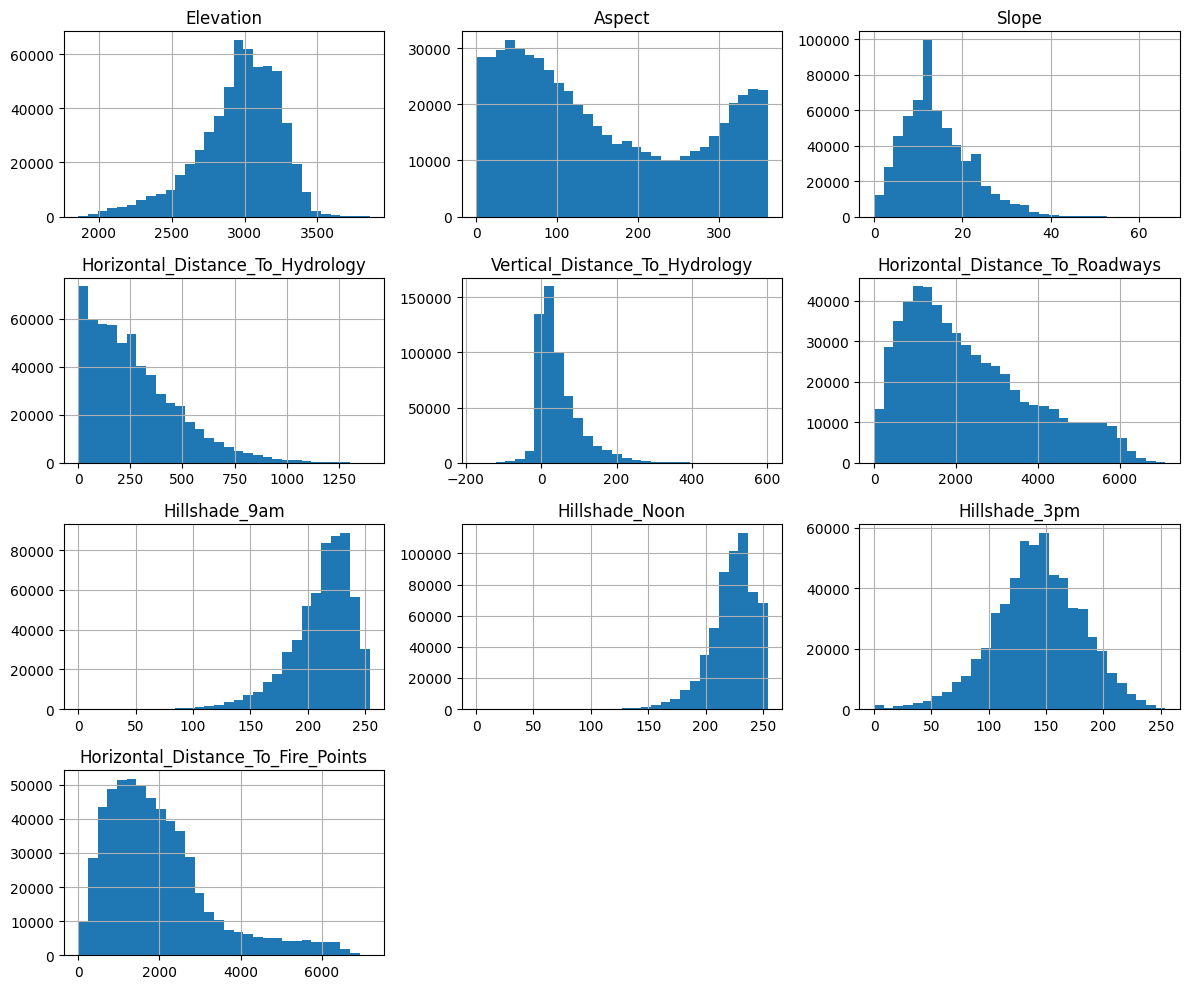

In [5]:
numeric = df.select_dtypes(include='number').loc[:,:'Horizontal_Distance_To_Fire_Points']

numeric.hist(figsize=(12, 10), bins=30)
plt.tight_layout()

### Distribution of Numerical Features Among Cover Types

We can see that Elevation appears to be the strongest individual predictor of Cover_Type. The average elevation within each tree type is different. From the first row, we can see that each tree class has vastly different elevation means.

In original units, plots of Krummholtz trees appear at very high elevations, around 3,000 meters, while Pine trees appear to be at much lower elevations, around 2,000 to 2,500 meters.

The horzontal distance to roadways/fire points also appear to be strong predictors. All the other variables appear to take on similar values among all classes. Feature Engineering will be needed to derive information from these variables.

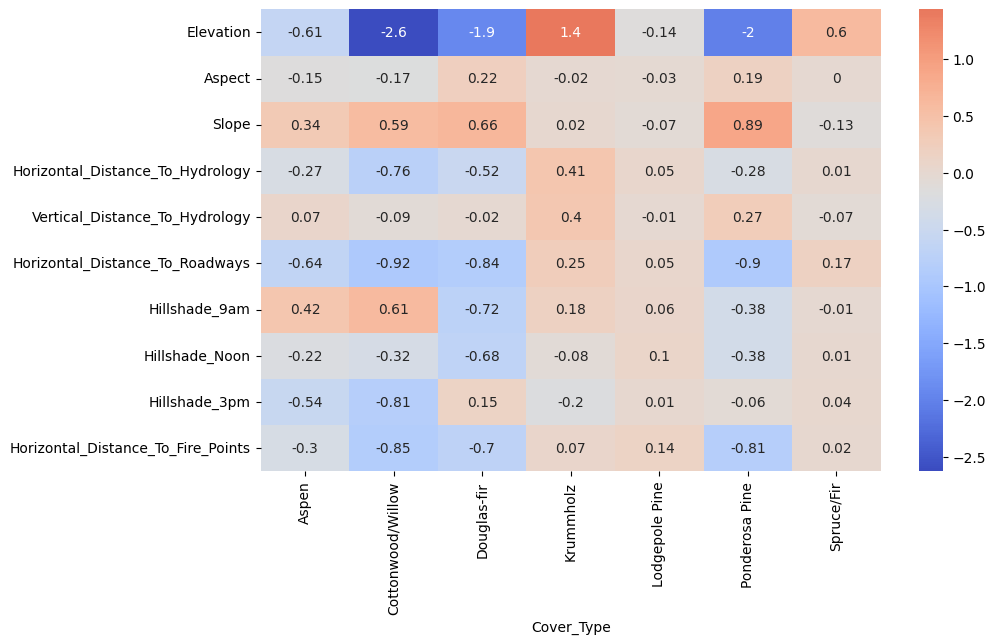

In [6]:
group_means = pd.concat([(numeric - numeric.mean())/numeric.std(), y], axis=1).groupby("Cover_Type").mean().round(2)

plt.figure(figsize=(10,6))
sns.heatmap(group_means.T, cmap='coolwarm', center=group_means.values.mean(), annot = True)
plt.show()

### Correlation Between Numerical Features

We can see that most of the variables are not highly correlated with each other. The hillshade variables appear to all have correlations with each other, which makes sense, because all describe hillshade on the same day at different times.

Slope and aspect, which correspond to the steepness of surface, and the direction of the slope respectively also appear to have linear relationships with hill shade.

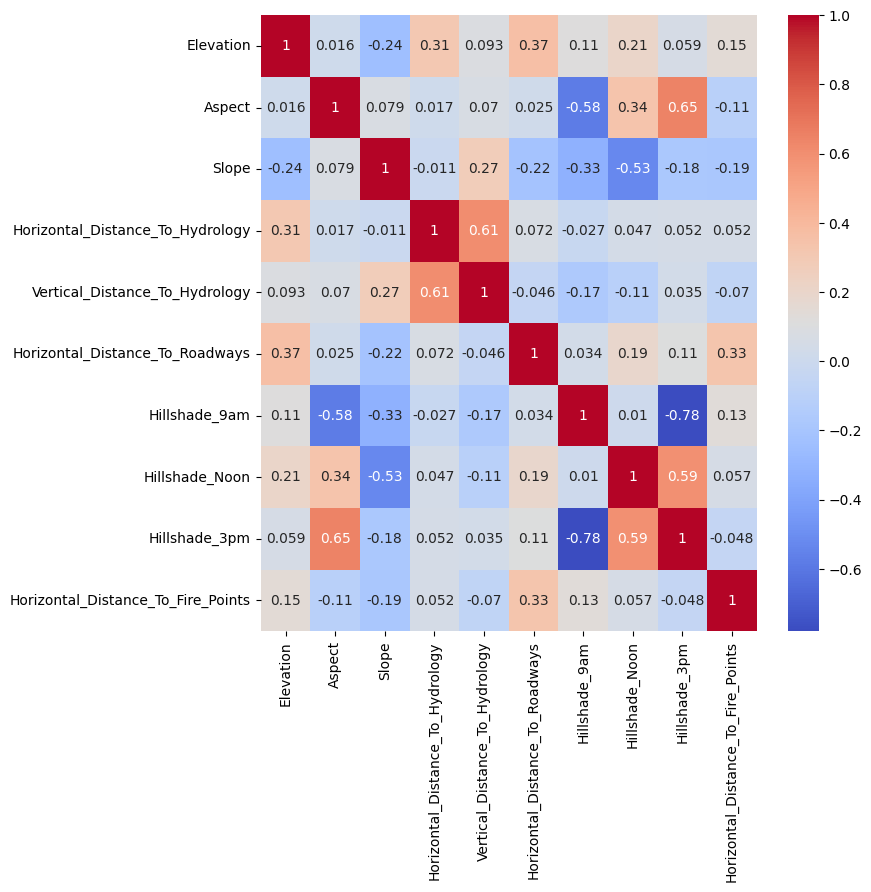

In [7]:
plt.figure(figsize=(8,8))
sns.heatmap(((numeric - numeric.mean()) / numeric.std()).cov(), cmap = 'coolwarm', annot = True)
plt.show()

## Categorical Features

The Categorical Features, Wilderness Area and soil type already come One Hot Encoded in the dataset. The below graph shows the proportion of each cover type in each wilderness area.

Notably, the Cottonwood/Willow  appears only in Wilderness Area 3. We can also see that most of the trees only appear in around 2 different wilderness areas in significant proportions.

<Axes: xlabel='Cover_Type'>

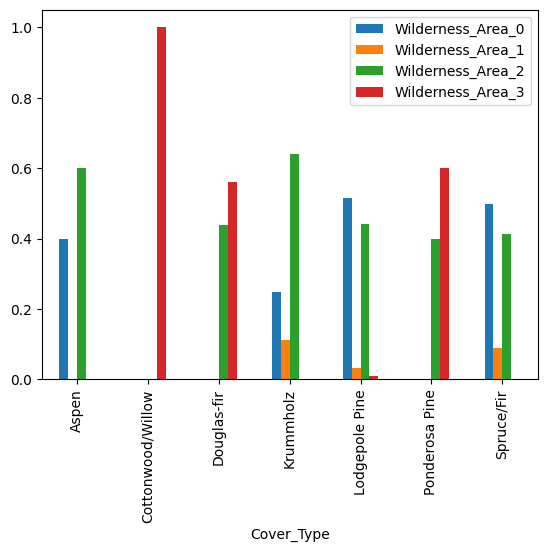

In [8]:
wildernessPerCover = df.groupby("Cover_Type")[["Wilderness_Area_0","Wilderness_Area_1","Wilderness_Area_2","Wilderness_Area_3"]].mean()

wildernessPerCover.plot.bar()

The below graph gives the proportion of each tree type in each soil type. Notably, most trees only appear in a few soil types. For example 50% of Douglas Fir patches have soil type 2, while 0% of Douglas Fir patches have soil type 6, or 8, or 11, etc.

Interestingly, soil types appear to be related to each other. If a high proportion of trees appear in soil type $i$, a decent proportion also seems to appear in soil types $i-2, i-1, i+1, i+2$.

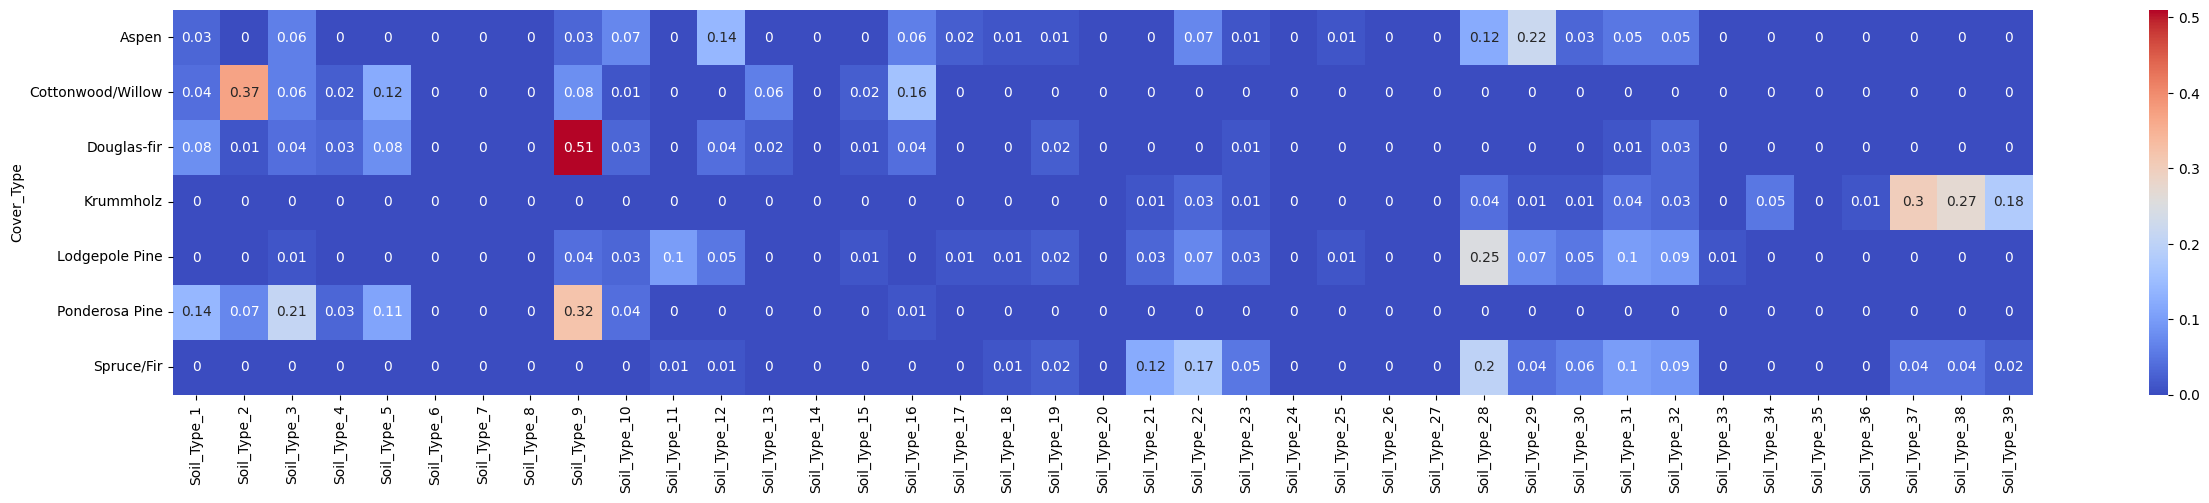

In [9]:
soilType = df.loc[:, "Soil_Type_1" : "Soil_Type_39"]
soilTypePerCover = pd.concat([soilType, y], axis = 1).groupby("Cover_Type").mean().round(2)
plt.figure(figsize=(30,5))
sns.heatmap(soilTypePerCover, cmap='coolwarm', annot=True)
plt.show()

# 2. Predictive Task

Our predictive task is predicting which cover type a 30 x 30m forest patch has, given 55 cartographic features. This is a classification problem. As stated earlier, class sizes are uneven, thus F1 Score is a strong evaluation metric. For the baseline models, I will use the simple classification models, like logistic regression and Naive Bayes.

# 3. Modelling

I am using a Random Forest Classifier for this predictive task.


## Feature Engineering

The following are engineered features:

1.)  $\text{Distance_To_Hydrology} = \sqrt{\text{Vertical_Distance_To_Hydrology}^2  + \text{Horizontal_Distance_To_Hydrology}^2}$

Reasoning: This variable represents the actual distance away from a forest plot to a water source, using the vertical and horizontal distance to hydrology. This feature interaction is fairly complex and has a meaningful interpretation, so including it directly will likely help the random forest.


2.) $\text{Eastness} = \sin(\text{Aspect})$ and $\text{Northness} = \cos(\text{Aspect})$

The aspect variable is the direction of slope in degrees on a compass, where $0^\circ$ is north. This variable is circular, $335^\circ \approx 0^\circ$. By taking the sine and cosine, we decompose the horizontal and vertical aspect, and make the feature not circular.

The cosine of aspect is maximized when aspect = 0, which is directly north. The sine of aspect is maximized when aspect is directly 90 CCW from north, which is East.

3.) Slope and Aspect Interaction Terms:
  
$\text{magnitudeEast} = \sin(\text{Aspect}) *\text{slope} =  \text{Eastness} * \text{slope}$

$\text{magnitudeNorth} = \cos(\text{Aspect}) *\text{slope} = \text{Northness} * \text{slope}$

The slope and aspect features are inherently related, as slope gives the steepness of the surface and aspect gives the direction in which the slope is pointing, thus explicitly adding this interaction can help the model.


## Feature Selection

From EDA, all of the of the numerical and categorical features appear to be meaningfully different across cover types. Thus, the models will include all features and the above engineered features.



In [10]:
def apply_features_and_scale(df):
  df = df.assign(Distance_To_Hydrology = (df["Vertical_Distance_To_Hydrology"]**2 + df["Horizontal_Distance_To_Hydrology"]**2)**0.5)

  df = df.assign(Northness = np.cos(np.deg2rad(df["Aspect"])))

  df = df.assign(Eastness = np.sin(np.deg2rad(df["Aspect"])))

  df = df.assign(magnitudeNorth = df["Northness"] * df["Slope"])

  df = df.assign(magnitudeEast = df["Eastness"] * df["Slope"])

  df = df.drop(["Aspect"], axis = 1)

  # Min-Max Scaling for Baseline Models
  df = (df - df.min(axis = 0))/(df.max(axis = 0) - df.min(axis = 0))

  return df.fillna(0)



In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

X_train_raw = X_train
X_test_raw = X_test

X_train = apply_features_and_scale(X_train)
X_test = apply_features_and_scale(X_test)

In [46]:
# Baselines
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
# Models
from sklearn.ensemble import RandomForestClassifier

In [14]:
# Random Forest
rfParams = {
    "n_estimators": [100,150,200],
    "max_depth": [None, 20, 15, 10, 5, 2],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", 0.1, 0.2, 0.3, 0.5, 0.7, 1]
}

rf = GridSearchCV(estimator= RandomForestClassifier(), param_grid = rfParams, cv = 5, scoring="f1_macro", n_jobs=-1)


Using GridSearchCV the optimal parameters are:

n_estimators = 200

max_depth = None

min_samples_leaf = 2

max_features = 0.3

In [56]:
nb = GaussianNB()
rf = RandomForestClassifier( n_estimators=200,max_depth=None,min_samples_leaf=2,max_features= 0.30, random_state = 1)
lr = LogisticRegression(C = 1.0, random_state= 1)
dt = DecisionTreeClassifier(max_depth = None)

In [49]:
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [16]:
nb.fit(X_train, y_train)

GaussianNB()

In [17]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_features=0.3, min_samples_leaf=2, n_estimators=200,
                       random_state=1)

In [53]:
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=1)

In [19]:
from sklearn.metrics import f1_score

In [54]:
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)
y_pred_nb = nb.predict(X_test)
y_pred_dt = dt.predict(X_test)

# 4. Literature

See write up

# 5. Results

## Performance Metrics

We can see that the Random Forest Classifier had a Macro-F1 Score of 0.89 and Accuracy of 93%, which were better results compared against Naive Bayes and Boosting.

In [55]:
rf_F1 = f1_score(y_test, y_pred_rf, average='macro')
lr_F1 = f1_score(y_test, y_pred_lr, average='macro')
nb_F1 = f1_score(y_test, y_pred_nb, average='macro')
dt_F1 = f1_score(y_test, y_pred_dt, average='macro')

rf_acc = (y_pred_rf == y_test).mean()
lr_acc = (y_pred_lr  == y_test).mean()
nb_acc = (y_pred_nb == y_test).mean()
dt_acc = (y_pred_dt == y_test).mean()


print(f"Naive Bayes Macro F1: {nb_F1}, Naive Bayes Accuracy: {nb_acc}")
print(f"Logistic Regression Macro F1: {lr_F1}, Logistic Regression Accuracy: {lr_acc}")
print(f"Decision Tree Macro F1: {dt_F1}, Decision Tree Accuracy: {dt_acc}")
print(f"Random Forest Macro F1: {rf_F1}, Random Forest Accuracy: {rf_acc}")

Naive Bayes Macro F1: 0.1247972164176122, Naive Bayes Accuracy: 0.09014397218660447
Logistic Regression Macro F1: 0.4950167166821241, Logistic Regression Accuracy: 0.7178472156484772
Decision Tree Macro F1: 0.8874125580779246, Decision Tree Accuracy: 0.9259313442854316
Random Forest Macro F1: 0.9337895854797713, Random Forest Accuracy: 0.9593986385893651


## Classification Errors and Confusion Matrices

Below are the confusion matrices for all models

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

We can see that the Random Forest is doing a good job at classifying the tree cover. A majority of errors the classifer makes are from misclassifying Spruce/Fir as Lodgepole Pine and vice versa.

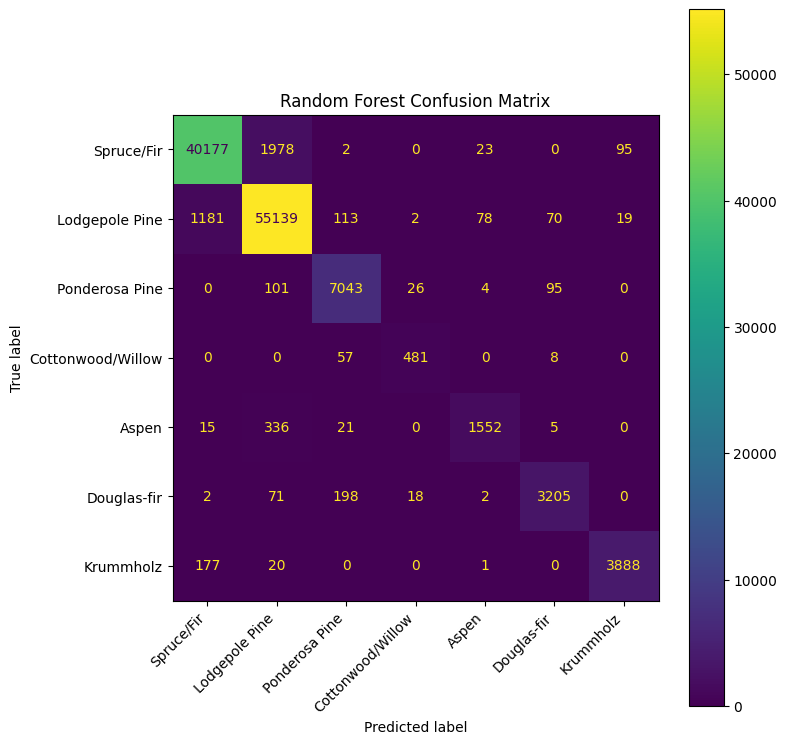

In [29]:
labels = list(map.values())
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Random Forest Confusion Matrix")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf,  labels = labels), display_labels = labels)
disp.plot(ax = ax,values_format='d')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Feature Importances

Below are the top 20 most important features in the Random Forest Classifier. Notably, all 5 engineered features appeared in the top 20, with Distance_To_Hydrology being the 5th most important feature, magnitudeNorth the 7th most important, magnitudeEast the 9th most important, Northness the 10th most important, and Eastness the 14th most important.

<Axes: >

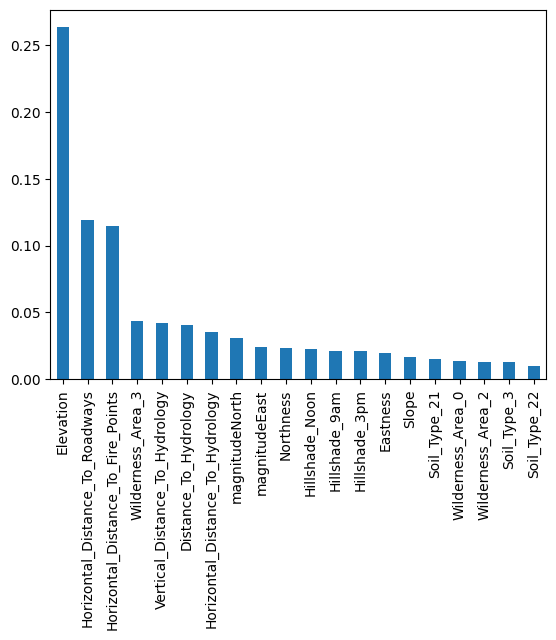

In [24]:
featImportance = pd.Series(index = X_train.columns, data = rf.feature_importances_)
featImportance = featImportance.sort_values(ascending = False).iloc[:20]

featImportance.plot.bar()

## Ablation Study

In [25]:
rf_raw = RandomForestClassifier(n_estimators=200,max_depth=None, min_samples_leaf=2, random_state = 1)
rf_raw.fit(X_train_raw, y_train)

RandomForestClassifier(min_samples_leaf=2, n_estimators=200, random_state=1)

In [26]:
y_pred_rf_raw = rf_raw.predict(X_test_raw)

raw_F1 = f1_score(y_test, y_pred_rf_raw, average='macro')

raw_acc = (y_pred_rf_raw == y_test).mean()

print(f"Random Forest No Feature Engineering Macro-F1: {raw_F1}, Random Forest No Feature Engineering Accuracy: {raw_acc}")
print(f"Random Forest Macro F1: {rf_F1}, Random Forest Accuracy: {rf_acc}")


Random Forest No Feature Engineering Macro-F1: 0.9179790173508106, Random Forest No Feature Engineering Accuracy: 0.9506295018200906
Random Forest Macro F1: 0.9337895854797713, Random Forest Accuracy: 0.9593986385893651
